# Plot benchmark results from existing CSV files

This notebook loads the CSV files produced by the benchmark and generates:

- a compact quantitative table for the three paper scenarios
- three grouped barplots for class retention:
  - Day-Rain
  - Sunset-Foggy
  - Night-Rain

It assumes the benchmark has already been run and the CSV files are available on disk.


In [1]:
from pathlib import Path

# ==== USER CONFIG ====
RESULTS_DIR = Path("./out_cityscapes_final")   # folder containing the CSV outputs
SAVE_DIR = RESULTS_DIR / "notebook_plots"

PLOT_SCENARIOS = ["Day-RAIN", "Sunset-FOGGY", "Night-RAIN"]
PLOT_DROP_CLASSNAME = "train"
MASS_COVERAGE = 0.99   # keep classes covering 99% of masked clean mass
TABLE_DECIMALS = 3

SAVE_DIR.mkdir(parents=True, exist_ok=True)
print("Results dir:", RESULTS_DIR.resolve())
print("Save dir:", SAVE_DIR.resolve())


Results dir: /drive/notebooks/out_cityscapes_final
Save dir: /drive/notebooks/out_cityscapes_final/notebook_plots


In [3]:
!mamba install pandas

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 0.8815 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ pandas                        3.0.1                         np22py313h9d9dc1e_0           emscripten-forge              
+ python-tzdata                 2025.3                        pyhd8ed1ab_0                  conda-forge                   
- pip                           25.3                          pyh145f28c_0                  conda-forge                   


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 140


In [6]:
def select_classes_by_mass_coverage(df_s: pd.DataFrame, coverage: float, drop_class: str = None):
    df = df_s.copy()
    if drop_class is not None:
        df = df[df["class_name"] != drop_class]

    mass_by_class = df.groupby("class_name")["mass_clean_masked"].sum().sort_values(ascending=False)
    total = float(mass_by_class.sum())
    if total < 1e-9:
        return []

    cum = mass_by_class.cumsum() / total
    keep = mass_by_class.index[cum <= coverage].tolist()

    if len(keep) == 0:
        keep = [mass_by_class.index[0]]
    elif cum.iloc[len(keep) - 1] < coverage and len(keep) < len(mass_by_class):
        keep.append(mass_by_class.index[len(keep)])

    return keep

def save_grouped_barplot(df_cls_cond: pd.DataFrame, scenario: str, save_dir: Path, mass_coverage: float, drop_class: str):
    df_s = df_cls_cond[df_cls_cond["sec_condition"] == scenario].copy()
    if df_s.empty:
        print(f"[warn] Scenario {scenario} not found.")
        return None

    keep_classes = select_classes_by_mass_coverage(df_s, coverage=mass_coverage, drop_class=drop_class)
    if not keep_classes:
        print(f"[warn] No classes selected for {scenario}.")
        return None

    df_s = df_s[df_s["class_name"].isin(keep_classes)].copy()
    piv = df_s.pivot_table(index="class_name", columns="model", values="retention_masked")
    piv = piv.reindex(keep_classes)

    fig = plt.figure(figsize=(12, 5))
    ax = fig.add_subplot(111)

    models = list(piv.columns)
    classes = list(piv.index)

    x = np.arange(len(classes))
    n_models = len(models)
    bar_width = 0.8 / max(n_models, 1)

    for j, m in enumerate(models):
        y = piv[m].values
        ax.bar(
            x + j * bar_width - (n_models - 1) * bar_width / 2,
            y,
            width=bar_width,
            label=m
        )

    ax.set_xticks(x)
    ax.set_xticklabels(classes, rotation=45, ha="right")
    ax.set_ylabel("Retention (masked)")
    ax.set_title(f"Class retention — {scenario} (mass coverage >= {mass_coverage:.0%})")
    ax.legend(fontsize=8, ncol=2)
    fig.tight_layout()

    out_path = save_dir / f"plot_bar_class_retention__{scenario}.png"
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print("Saved:", out_path)
    return piv


In [8]:
df_cond = pd.read_csv(RESULTS_DIR / "results_pixel_agreement_by_condition.csv")
df_cls_cond = pd.read_csv(RESULTS_DIR / "results_class_retention_by_condition.csv")

print("Condition summary rows:", len(df_cond))
print("Class retention rows:", len(df_cls_cond))
df_cond.head()


Condition summary rows: 40
Class retention rows: 760


,model,sec_condition,pixel_agreement_masked_mean,n_pairs,conf_threshold
0,SegFormer-B0,Sunset-FOGGY,0.860322,13,0.6
1,SegFormer-B0,Day-RAIN,0.917924,18,0.6
2,SegFormer-B0,Day-FOGGY,0.949279,20,0.6
3,SegFormer-B0,Sunset-EXTRASUNNY,0.912767,12,0.6
4,SegFormer-B0,Night-RAIN,0.645500,13,0.6


In [9]:
table_df = (
    df_cond[df_cond["sec_condition"].isin(PLOT_SCENARIOS)]
    .pivot(index="model", columns="sec_condition", values="pixel_agreement_masked_mean")
    .reindex(columns=PLOT_SCENARIOS)
)
table_df = table_df.assign(_avg=table_df.mean(axis=1)).sort_values("_avg", ascending=False).drop(columns="_avg")
table_df_rounded = table_df.round(TABLE_DECIMALS)
table_df_rounded


sec_condition,Day-RAIN,Sunset-FOGGY,Night-RAIN
model,,,
Mask2Former-Swin-L,0.934,0.871,0.842
SegFormer-B2,0.931,0.893,0.669
Mask2Former-Swin-S,0.928,0.870,0.681
SegFormer-B5,0.934,0.860,0.649
SegFormer-B0,0.918,0.860,0.646


In [10]:
table_out = SAVE_DIR / "paper_quantitative_table.csv"
table_df_rounded.to_csv(table_out)
print("Saved:", table_out)


Saved: out_cityscapes_final/notebook_plots/paper_quantitative_table.csv


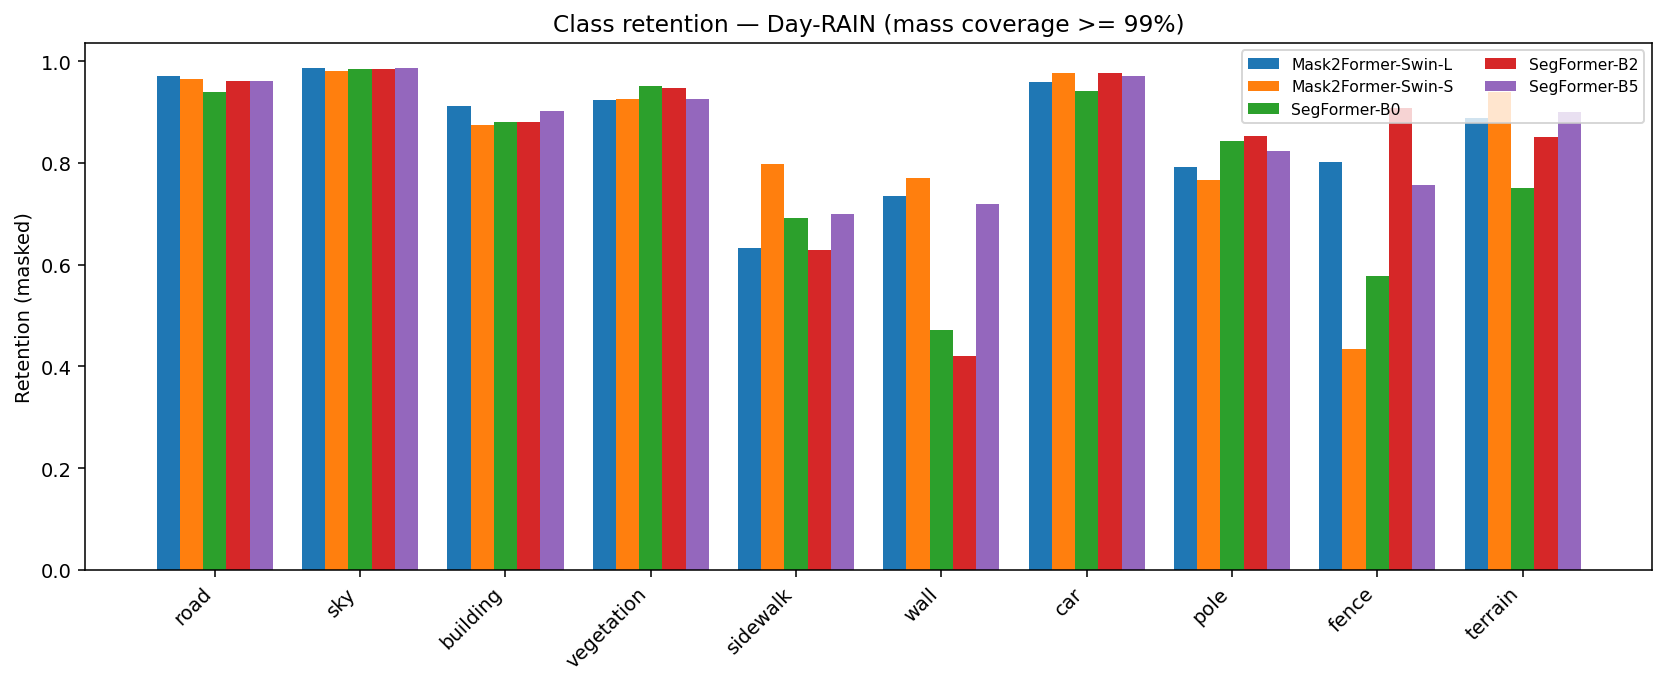

Saved: out_cityscapes_final/notebook_plots/plot_bar_class_retention__Day-RAIN.png


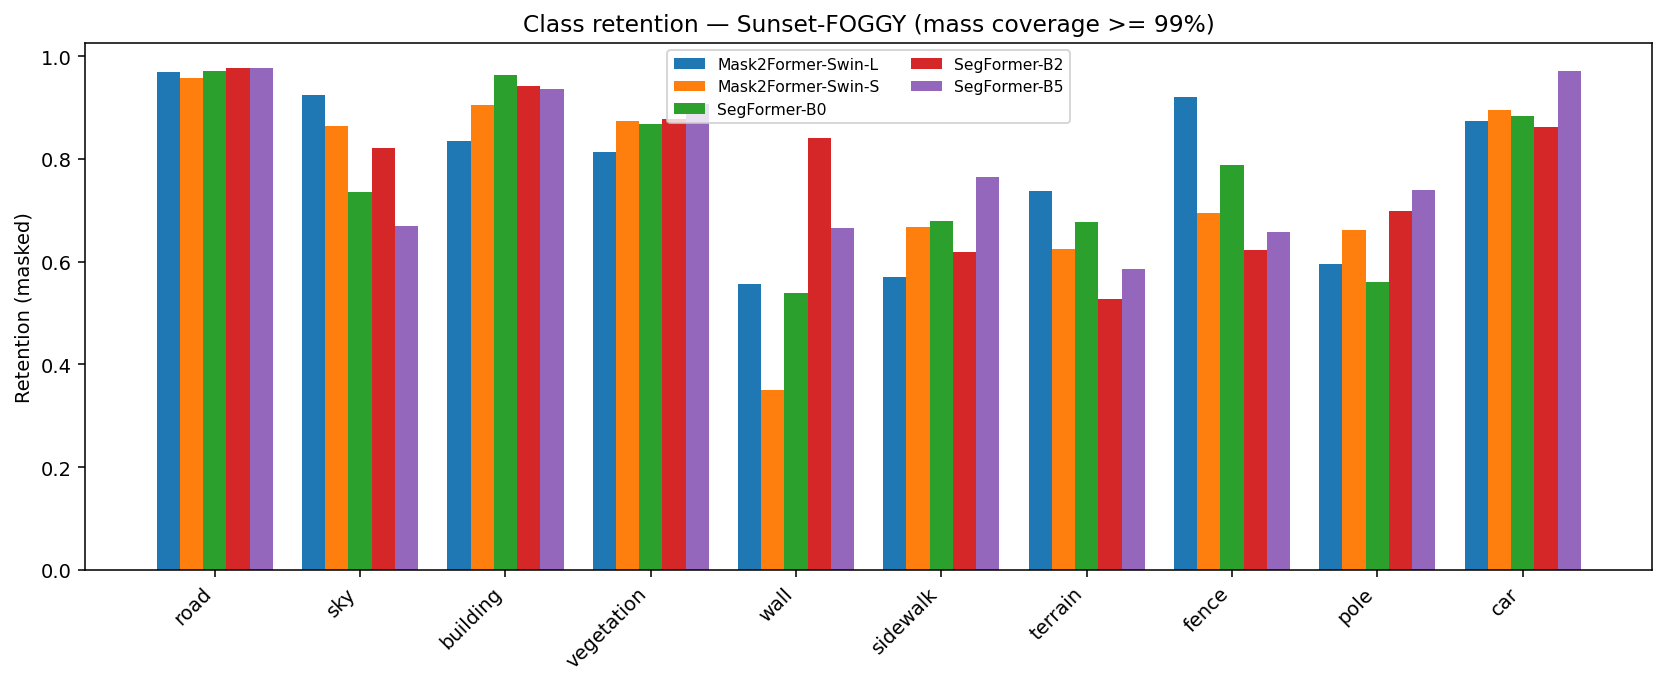

Saved: out_cityscapes_final/notebook_plots/plot_bar_class_retention__Sunset-FOGGY.png


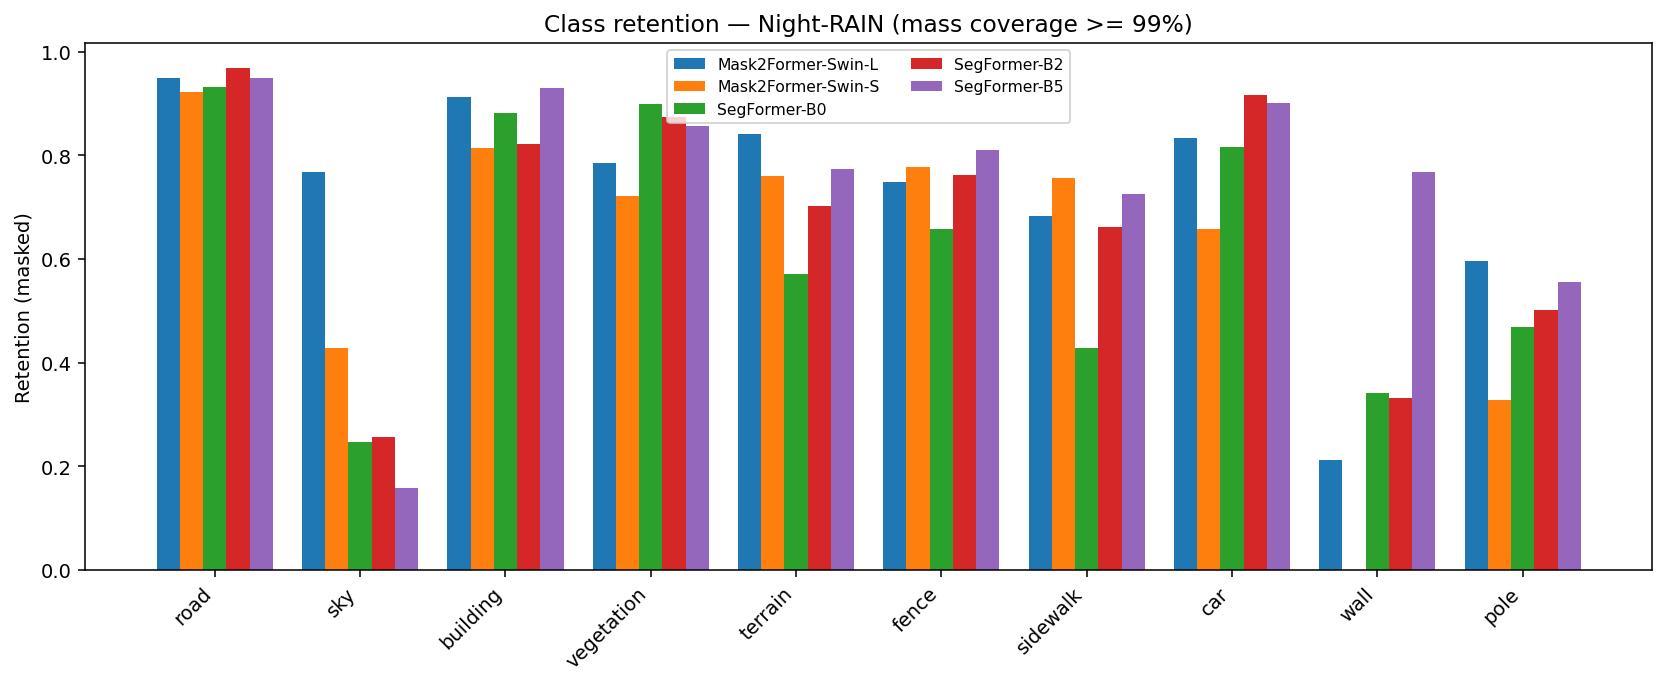

Saved: out_cityscapes_final/notebook_plots/plot_bar_class_retention__Night-RAIN.png


In [11]:
pivots = {}
for scen in PLOT_SCENARIOS:
    pivots[scen] = save_grouped_barplot(
        df_cls_cond=df_cls_cond,
        scenario=scen,
        save_dir=SAVE_DIR,
        mass_coverage=MASS_COVERAGE,
        drop_class=PLOT_DROP_CLASSNAME,
    )


## Notes

- `results_pixel_agreement_by_condition.csv` is used for the compact quantitative table.
- `results_class_retention_by_condition.csv` is used for the class-retention barplots.
- The class `train` is removed only from the plots.
- The plotted classes are selected automatically using mass coverage, exactly as in the benchmark script.
